<a href="https://colab.research.google.com/github/khanuja74/khanuja74/blob/main/EVINDIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ELECTRIC VEHICLE SALES BY STATE IN INDIA**


***IMPORT LIBRARIES***


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
import warnings
warnings.filterwarnings("ignore")
from IPython.display import Markdown
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


***LOADING DATASET***

In [ ]:
df = pd.read_csv("Electric-Vehicle-Sales-by-State-in-India.csv",
                 engine='python',          # allows advanced parsing
                 on_bad_lines='skip',      # skips lines with parsing errors
                 encoding_errors='ignore') # ignores text encoding errors

# Confirmation message
print(" Data Loaded Successfully!\n")

# Show the shape (rows, columns)
print("Shape of dataset:", df.shape)

# Show the first 5 rows
print("\nPreview:")
print(df.head())

 Data Loaded Successfully!

Shape of dataset: (96845, 8)

Preview:
   Year Month_Name        Date           State         Vehicle_Class  \
0  2014        jan  01-01-2014  Andhra Pradesh       ADAPTED VEHICLE   
1  2014        jan  01-01-2014  Andhra Pradesh  AGRICULTURAL TRACTOR   
2  2014        jan  01-01-2014  Andhra Pradesh             AMBULANCE   
3  2014        jan  01-01-2014  Andhra Pradesh   ARTICULATED VEHICLE   
4  2014        jan  01-01-2014  Andhra Pradesh                   BUS   

  Vehicle_Category Vehicle_Type  EV_Sales_Quantity  
0           Others       Others                  2  
1           Others       Others                  6  
2           Others       Others                  9  
3           Others       Others                  2  
4              Bus          Bus                 33  


***DATA REVIEW***

In [ ]:
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               96845 non-null  int64 
 1   Month_Name         96845 non-null  object
 2   Date               96845 non-null  object
 3   State              96845 non-null  object
 4   Vehicle_Class      96845 non-null  object
 5   Vehicle_Category   96845 non-null  object
 6   Vehicle_Type       96845 non-null  object
 7   EV_Sales_Quantity  96845 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 5.9+ MB
None

Missing Values:
Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64


***DATA CLEANING***

In [ ]:
# Convert 'Year' safely to integer
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')

# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Convert selected columns to 'category' type if they exist
categorical_cols = ['Month_Name', 'State', 'Vehicle_Class', 'Vehicle_Category', 'Vehicle_Type']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

#  Display cleaned data info
print("\n Cleaned Data Info:")
print(df.info())

#  Check for missing values
print("\n Missing Values Summary:")
print(df.isnull().sum())

#  Basic Statistical Summary
print("\n Statistical Summary (Numeric Columns):")
print(df.describe())

#  Summary for categorical columns (optional)
print("\n Categorical Summary:")
print(df[categorical_cols].describe())



 Cleaned Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Year               96845 non-null  Int64         
 1   Month_Name         96845 non-null  category      
 2   Date               96845 non-null  datetime64[ns]
 3   State              96845 non-null  category      
 4   Vehicle_Class      96845 non-null  category      
 5   Vehicle_Category   96845 non-null  category      
 6   Vehicle_Type       96845 non-null  category      
 7   EV_Sales_Quantity  96845 non-null  int64         
dtypes: Int64(1), category(5), datetime64[ns](1), int64(1)
memory usage: 2.8 MB
None

 Missing Values Summary:
Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64

 Statistical

***DATA STATISTICS***

In [ ]:
print("\nDescriptive Statistics:")
print(df.describe())



Descriptive Statistics:
              Year                           Date  EV_Sales_Quantity
count      96845.0                          96845       96845.000000
mean   2018.622768  2019-01-28 11:00:33.641385728          37.125933
min         2014.0            2014-01-01 00:00:00           0.000000
25%         2016.0            2016-08-01 00:00:00           0.000000
50%         2019.0            2019-02-01 00:00:00           0.000000
75%         2021.0            2021-09-01 00:00:00           0.000000
max         2024.0            2024-01-01 00:00:00       20584.000000
std       2.895581                            NaN         431.574493


***DATA VISUALIZTION***


**[A] YEARLY TREND OF EV SALES**

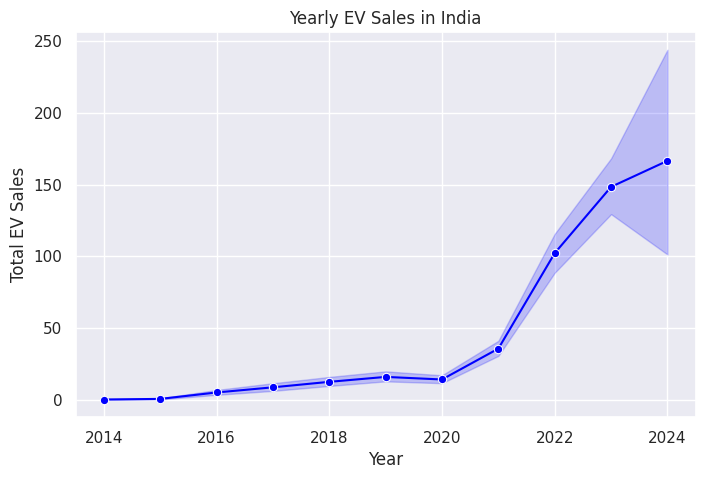

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(x='Year', y='EV_Sales_Quantity', data=df, marker='o', color='blue')
plt.title("Yearly EV Sales in India")
plt.xlabel("Year")
plt.ylabel("Total EV Sales")
plt.show()


**[B] MONTHLY EV SALES TREND**


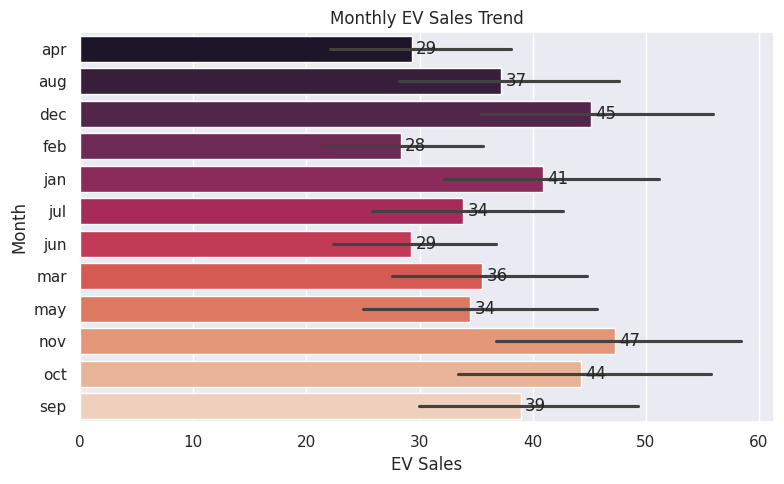

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.barplot(y='Month_Name', x='EV_Sales_Quantity', data=df, palette='rocket')

plt.title("Monthly EV Sales Trend")
plt.xlabel("EV Sales")
plt.ylabel("Month")

# Add data labels
for i in ax.containers:
    ax.bar_label(i, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()



**[C] STATE WISE EV SALES**


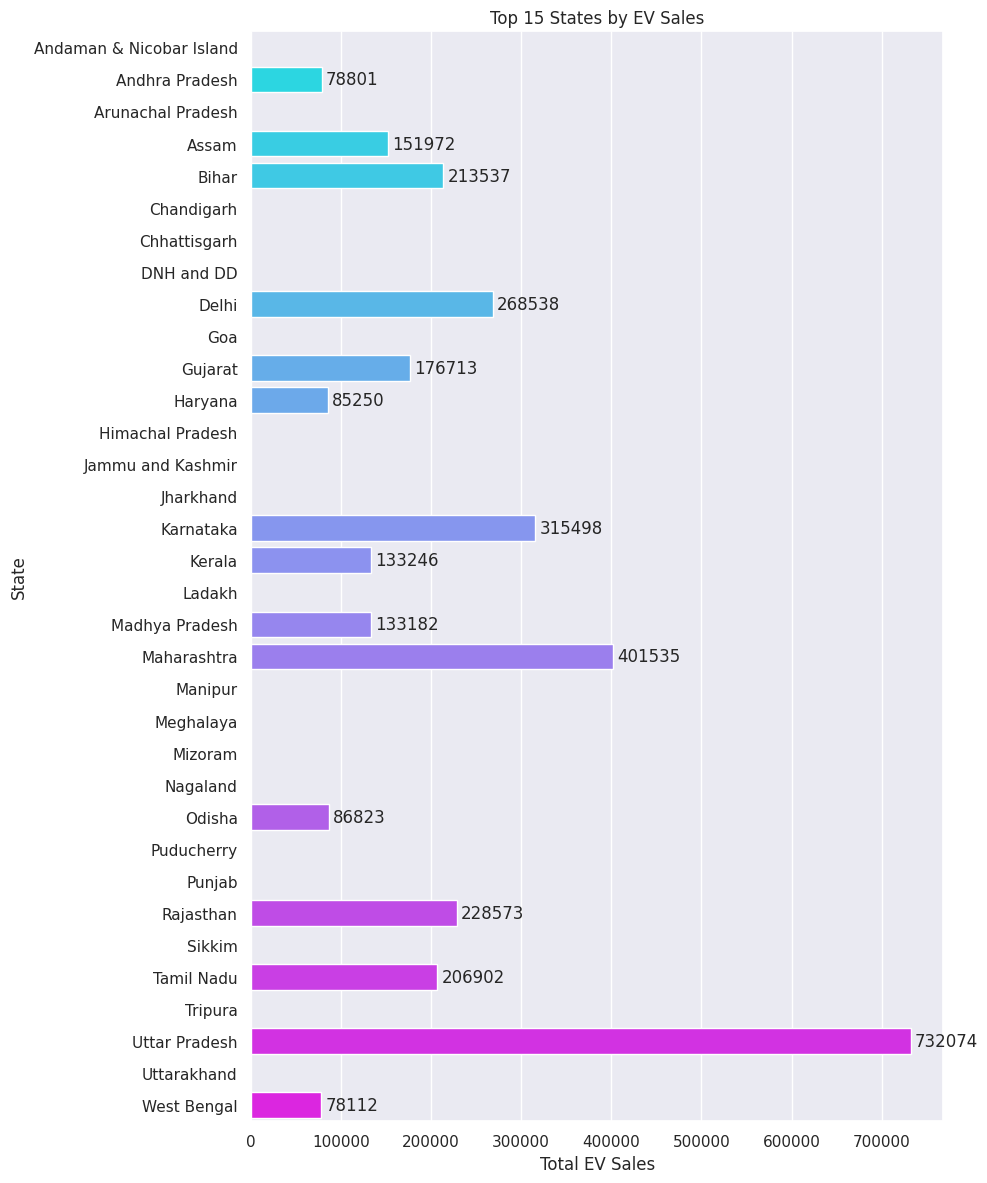

In [ ]:
plt.figure(figsize=(10,12))

top_states = (
    df.groupby('State')['EV_Sales_Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

ax = sns.barplot(
    x=top_states.values,
    y=top_states.index,
    palette='cool'
)

plt.title("Top 15 States by EV Sales")
plt.xlabel("Total EV Sales")
plt.ylabel("State")

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()


**[D] EV SALES BY VEHICLE CLASS**

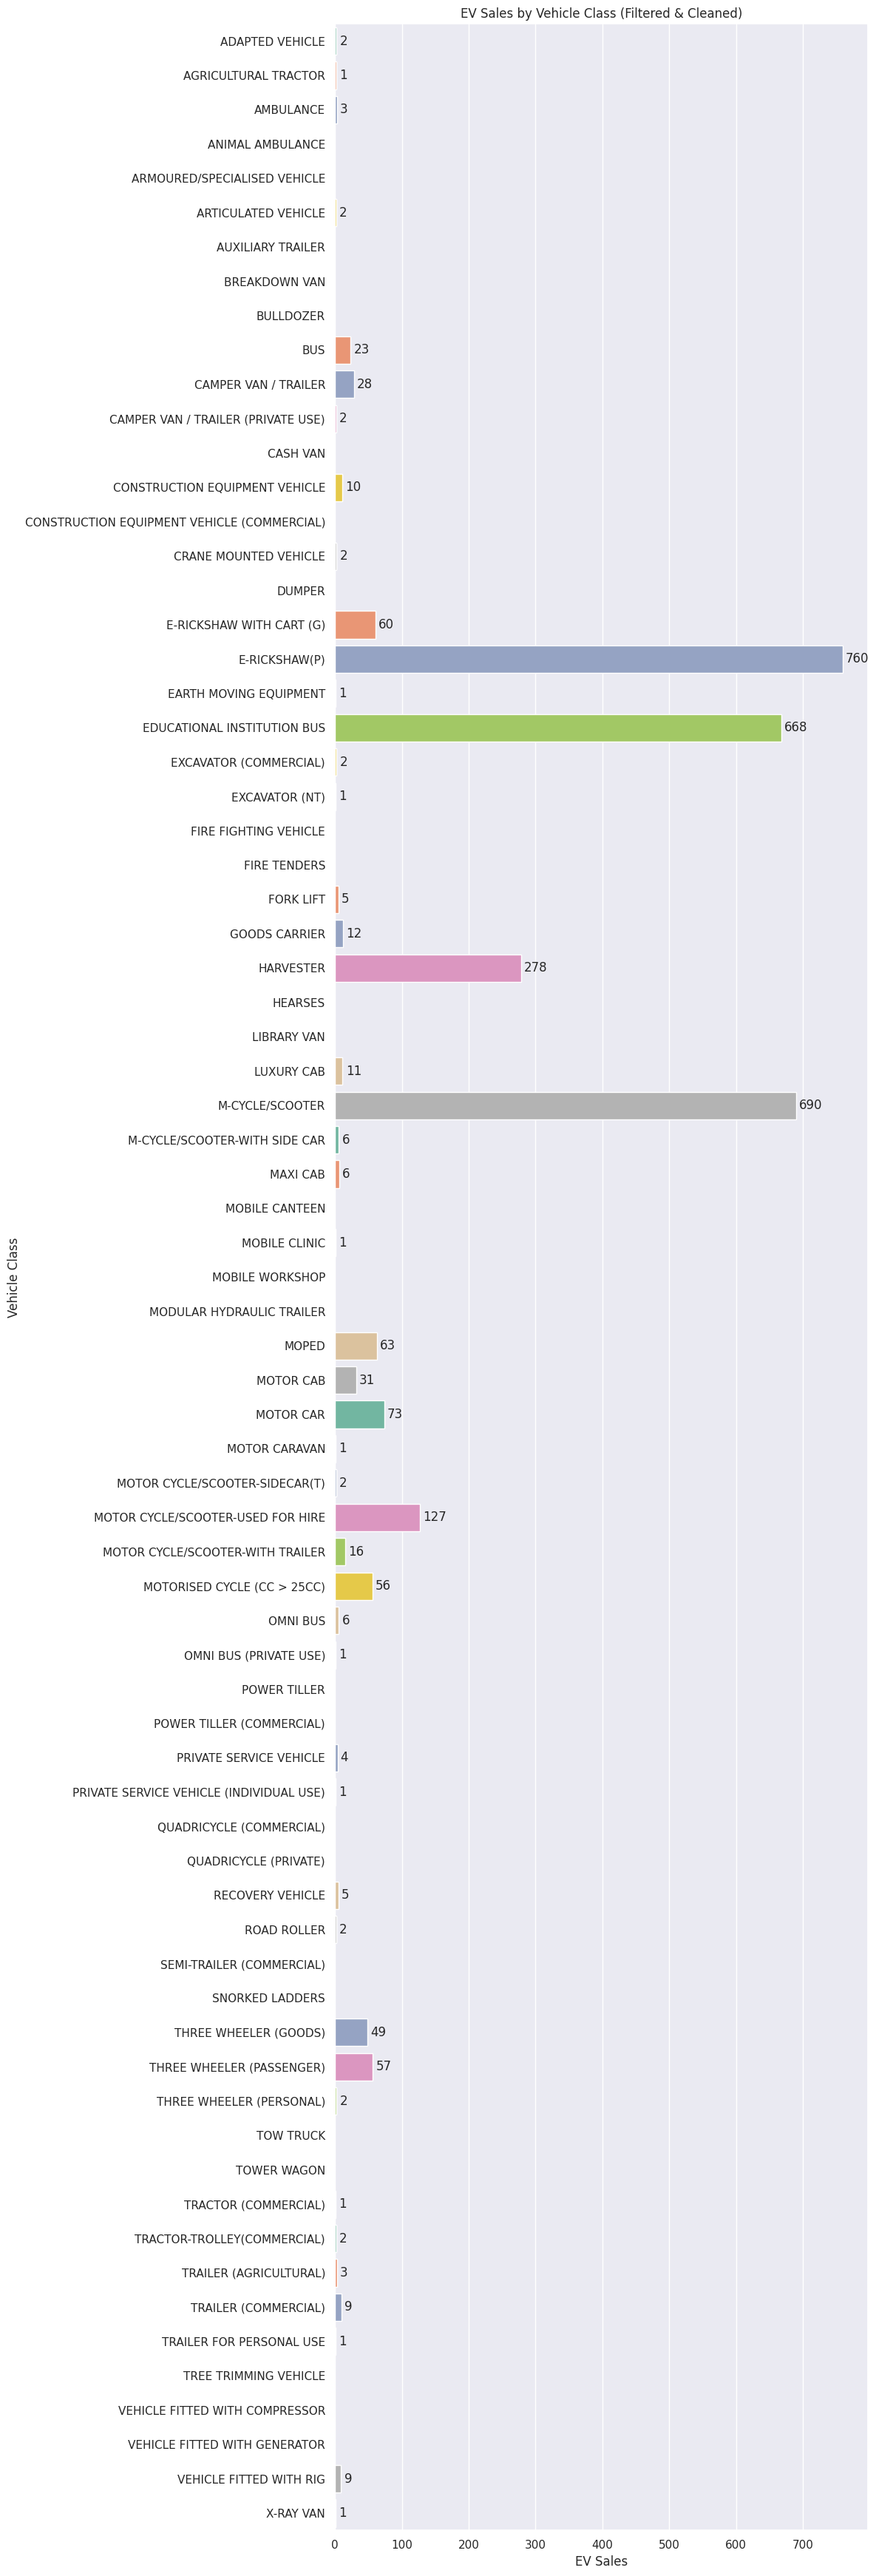

In [ ]:
# 1 Filter rows where sales > 0
df_clean = df[df['EV_Sales_Quantity'] > 0]

# 2 Remove unwanted Vehicle_Class groups whose total sales = 0
valid_classes = (
    df_clean.groupby('Vehicle_Class')['EV_Sales_Quantity']
    .sum()
    .loc[lambda x: x > 0]
    .index
)

df_clean = df_clean[df_clean['Vehicle_Class'].isin(valid_classes)]

# 3 Horizontal bar chart
plt.figure(figsize=(12,35))
ax = sns.barplot(
    y='Vehicle_Class',
    x='EV_Sales_Quantity',
    data=df_clean,
    palette='Set2',
    ci=None
)

plt.title("EV Sales by Vehicle Class (Filtered & Cleaned)")
plt.xlabel("EV Sales")
plt.ylabel("Vehicle Class")

# 4 Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()


**[E] EV SALES BY VEHICLE CATEGORY**

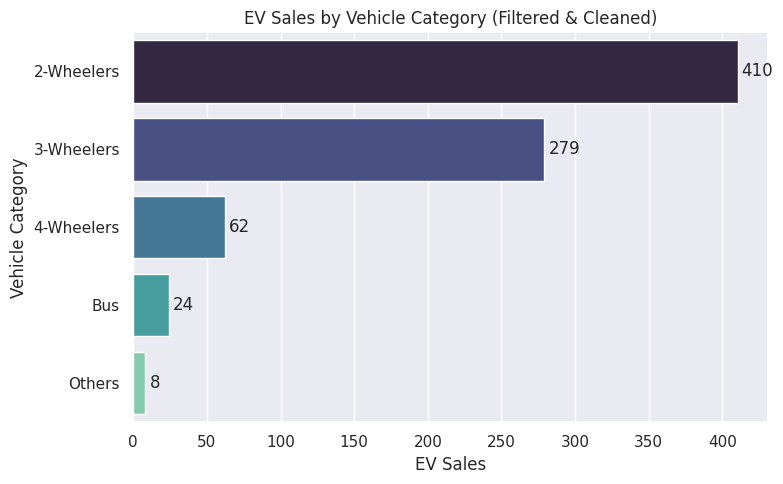

In [ ]:
# 1 Filter rows with EV_Sales_Quantity > 0
df_clean = df[df['EV_Sales_Quantity'] > 0]

# 2 Remove Vehicle_Category groups whose total sales = 0
valid_categories = (
    df_clean.groupby('Vehicle_Category')['EV_Sales_Quantity']
    .sum()
    .loc[lambda x: x > 0]
    .index
)

df_clean = df_clean[df_clean['Vehicle_Category'].isin(valid_categories)]

# 3 Horizontal bar chart
plt.figure(figsize=(8,5))
ax = sns.barplot(
    y='Vehicle_Category',
    x='EV_Sales_Quantity',
    data=df_clean,
    palette='mako',
    ci=None
)

plt.title("EV Sales by Vehicle Category (Filtered & Cleaned)")
plt.xlabel("EV Sales")
plt.ylabel("Vehicle Category")

# 4 Add data labels
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()


**[F] EV SALES BY VEHICLE TYPE**


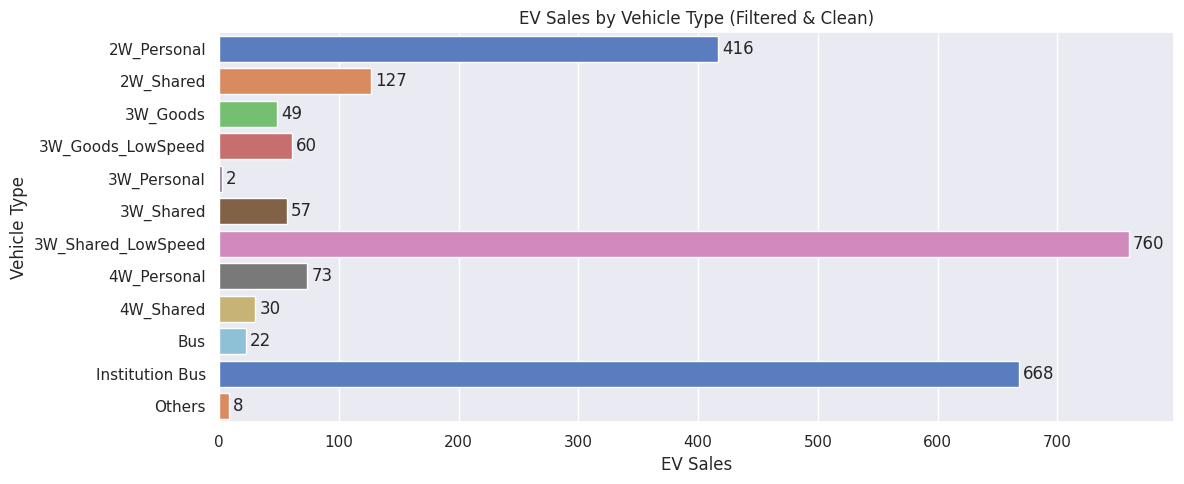

In [ ]:
# 1️⃣ Filter rows with EV_Sales_Quantity > 0
df_clean = df[df['EV_Sales_Quantity'] > 0]

# 2️⃣ Remove Vehicle_Type groups whose total sales = 0
valid_types = (
    df_clean.groupby('Vehicle_Type')['EV_Sales_Quantity']
    .sum()
    .loc[lambda x: x > 0]
    .index
)

df_clean = df_clean[df_clean['Vehicle_Type'].isin(valid_types)]

# 3️⃣ Horizontal bar chart
plt.figure(figsize=(12,5))
ax = sns.barplot(
    y='Vehicle_Type',
    x='EV_Sales_Quantity',
    data=df_clean,
    palette='muted',
    ci=None
)

plt.title("EV Sales by Vehicle Type (Filtered & Clean)")
plt.xlabel("EV Sales")
plt.ylabel("Vehicle Type")

# 4️⃣ Add data labels
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()


**[7] KEY INSIGHTS**

In [ ]:
print("\n INSIGHTS:")

# 1 Total Records
print(f"1 Total Records: {len(df)}")

# 2 Time Range
print(f"2 Time Range: {df['Year'].min()} to {df['Year'].max()}")

# 3 Highest Selling State (based on total EV sales)
state_sales = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False)
print(f"3 Highest Selling State: {state_sales.index[0]} ({state_sales.iloc[0]} sales)")

# 4 Highest Vehicle Category (based on total EV sales)
category_sales = df.groupby('Vehicle_Category')['EV_Sales_Quantity'].sum().sort_values(ascending=False)
print(f"4 Highest Vehicle Category: {category_sales.index[0]} ({category_sales.iloc[0]} sales)")

# 5 Average EV Sales Quantity
print(f"5 Average EV Sales Quantity: {df['EV_Sales_Quantity'].mean():.2f}")



 INSIGHTS:
1 Total Records: 96845
2 Time Range: 2014 to 2024
3 Highest Selling State: Uttar Pradesh (732074 sales)
4 Highest Vehicle Category: 2-Wheelers (1808105 sales)
5 Average EV Sales Quantity: 37.13
